# Trader Behavior vs Market Sentiment Analysis
Data Science Internship Assignment – Primetrade.ai

## Objective

The goal of this analysis is to understand how market sentiment (Fear vs Greed)
affects trader behavior and performance.

We analyze historical Hyperliquid trading data and Bitcoin market sentiment
to identify patterns in profitability, trade activity, and risk-taking behavior.

## Data Preparation

In [91]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sentiment = pd.read_csv("data/sentiment.csv")
trades = pd.read_csv("data/trader_data.csv")

### Dataset Overview

In [92]:
print("Sentiment dataset shape:", sentiment.shape)
print("Trader dataset shape:", trades.shape)

sentiment.head()
trades.head()

Sentiment dataset shape: (2644, 4)
Trader dataset shape: (211224, 16)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [93]:
sentiment.info()
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-nu

### Timestamp Processing
Trader timestamps were converted from Unix format to datetime
and aligned with daily sentiment data.

In [94]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')
trades['date'] = trades['Timestamp'].dt.date

sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

### Data Alignment

The sentiment dataset was merged with trading data using the date field.

In [95]:
data = pd.merge(trades, sentiment[['date','classification']], on='date', how='left')
data.rename(columns={'classification':'Sentiment'}, inplace=True)

data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,Sentiment
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,Greed


## Key Metrics

In [96]:
daily_pnl = data.groupby(['Account','date'])['Closed PnL'].sum().reset_index()
daily_pnl.head()

,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,1.017915e+04


In [97]:
data.groupby('Sentiment').size()

Sentiment
Extreme Greed      6962
Fear             133871
Greed             36289
Neutral            7141
dtype: int64

In [98]:
data.groupby('Sentiment')['Size USD'].mean()

Sentiment
Extreme Greed    5660.265764
Fear             5259.977837
Greed            3182.883845
Neutral          3058.848110
Name: Size USD, dtype: float64

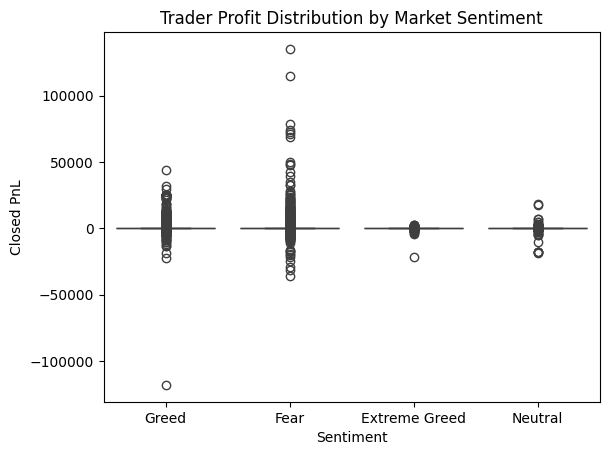

In [99]:
sns.boxplot(x='Sentiment', y='Closed PnL', data=data)

plt.title("Trader Profit Distribution by Market Sentiment")

plt.show()

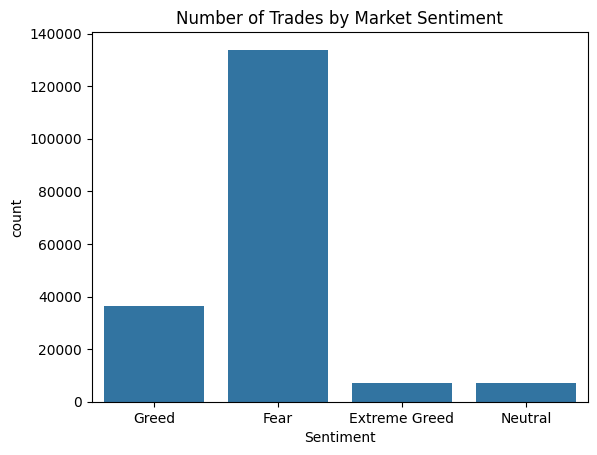

In [100]:
sns.countplot(x='Sentiment', data=data)

plt.title("Number of Trades by Market Sentiment")

plt.show()

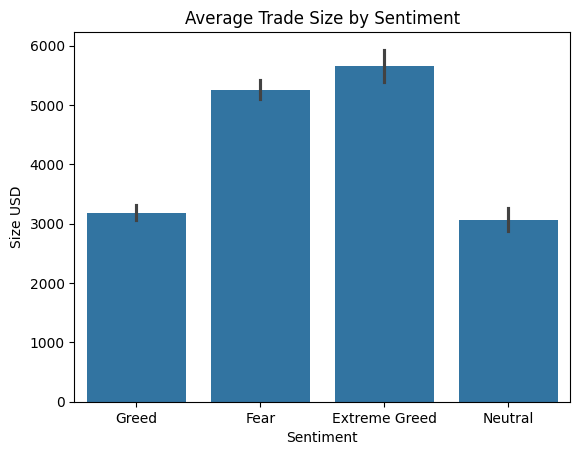

In [101]:
sns.barplot(x='Sentiment', y='Size USD', data=data)

plt.title("Average Trade Size by Sentiment")

plt.show()

## Trader Segmentation

In [102]:
trade_counts = data.groupby('Account').size()

data['Trader_Frequency'] = data['Account'].map(
    lambda x: 'Frequent' if trade_counts[x] > trade_counts.median() else 'Infrequent'
)

In [103]:
trader_profit = data.groupby('Account')['Closed PnL'].sum()

data['Trader_Result'] = data['Account'].map(
    lambda x: 'Winner' if trader_profit[x] > 0 else 'Loser'
)

## Key Insights

1. Traders achieve the highest average profits during Greed sentiment periods,
indicating bullish markets provide stronger trading opportunities.

2. Trading activity peaks during Fear periods, suggesting volatility drives
higher trading frequency.

3. Traders take larger position sizes during extreme market sentiment
(Fear or Extreme Greed), indicating higher risk-taking behavior.

## Strategy Recommendations

Strategy 1:
Momentum-based trading strategies perform best during Greed markets.
Traders can increase exposure during bullish sentiment conditions.

Strategy 2:
Risk management becomes critical during Fear periods due to high volatility.
Smaller position sizes and tighter stop-loss strategies may reduce risk.

In [ ]:
trader_sentiment_analysis.ipynb